In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import MinMaxScaler

In [2]:
df=pd.read_csv(r"E:\Visualization\Lab_main\Data\housing.csv")
df.head(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


# Bai 1

In [3]:
df = pd.get_dummies(
    df,
    columns=['ocean_proximity'],
    drop_first=True
)

In [4]:
corr_matrix = df.corr() 
corr_matrix


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069608,0.099773,0.055310,-0.015176,-0.045967,-0.055575,0.009446,-0.474489,0.045509
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066983,-0.108785,-0.071035,-0.079809,-0.144160,0.351166,-0.016572,0.358771,-0.160818
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.320451,-0.296244,-0.302916,-0.119034,0.105623,-0.236645,0.017020,0.255172,0.021622
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.930380,0.857126,0.918484,0.198050,0.134153,0.025624,-0.007572,-0.023022,-0.009175
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686,-0.006463,-0.004361,-0.019873,0.000679
population,0.099773,-0.108785,-0.296244,0.857126,0.877747,1.000000,0.907222,0.004834,-0.024650,-0.020732,-0.010412,-0.060880,-0.024264
households,0.055310,-0.071035,-0.302916,0.918484,0.979728,0.907222,1.000000,0.013033,0.065843,-0.039402,-0.009077,-0.010093,0.001714
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007723,0.004834,0.013033,1.000000,0.688075,-0.237496,-0.009228,0.056197,0.027344
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049686,-0.024650,0.065843,0.688075,1.000000,-0.484859,0.023416,0.160284,0.141862
ocean_proximity_INLAND,-0.055575,0.351166,-0.236645,0.025624,-0.006463,-0.020732,-0.039402,-0.237496,-0.484859,1.000000,-0.010614,-0.240887,-0.262163


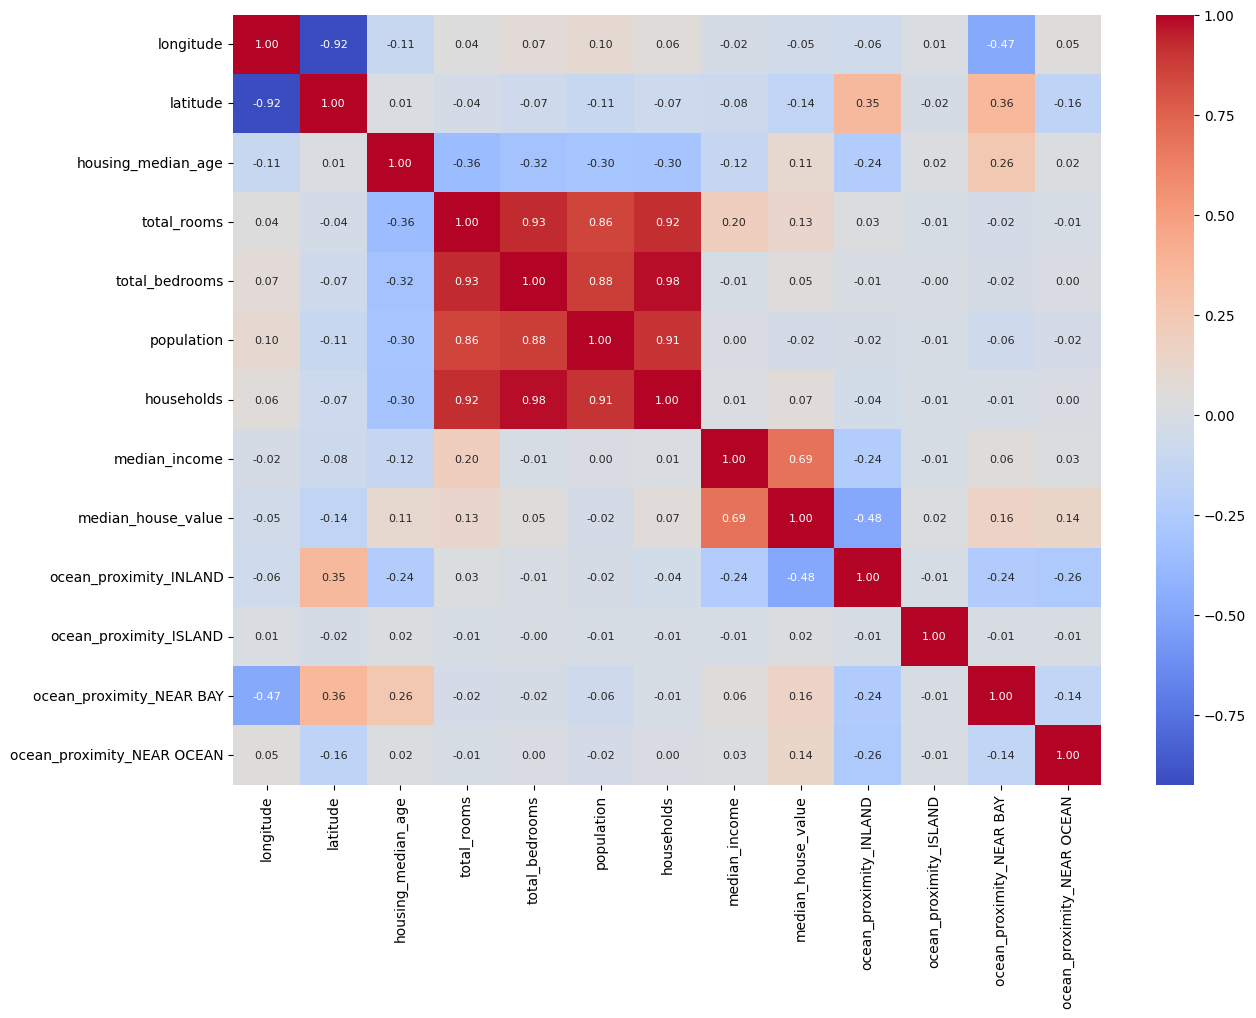

In [6]:
plt.figure(figsize=(14,10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    annot_kws={"size":8},
    cmap='coolwarm'
)
plt.show()

# Bai 2

# Hiển thị thu nhập

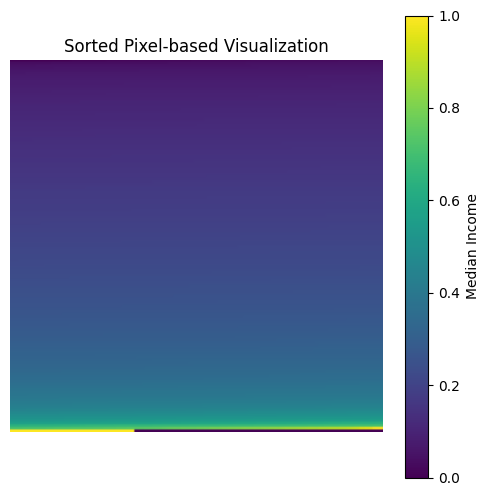

In [18]:
values = MinMaxScaler().fit_transform(df[["median_income"]]).flatten()

values = np.sort(values)

size = int(np.ceil(np.sqrt(len(values))))

pixel_matrix = np.zeros(size * size)
pixel_matrix[: len(values)] = values

pixel_matrix = pixel_matrix.reshape(size, size)

plt.figure(figsize=(6, 6))
plt.imshow(pixel_matrix, cmap="viridis")
plt.colorbar(label="Median Income")
plt.title("Sorted Pixel-based Visualization")
plt.axis("off")
plt.show()

# Bai 3

In [27]:
features = [
    'median_income',
    'housing_median_age',
    'total_rooms',
    'population',
    'latitude',
    'median_house_value'
]

In [28]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[features])

In [29]:
def star_plot(values, labels, title):

    N = len(values)

    angles = np.linspace(0, 2 * np.pi, N, endpoint=False)

    values = np.concatenate([values, [values[0]]])
    angles = np.concatenate([angles, [angles[0]]])

    fig = plt.figure(figsize=(6, 6))
    ax = plt.subplot(111, polar=True)

    ax.plot(angles, values)
    ax.fill(angles, values, alpha=0.3)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels)

    ax.set_title(title)

    plt.show()

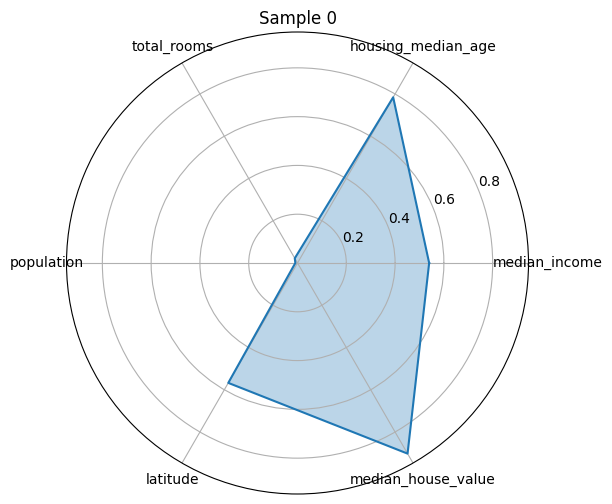

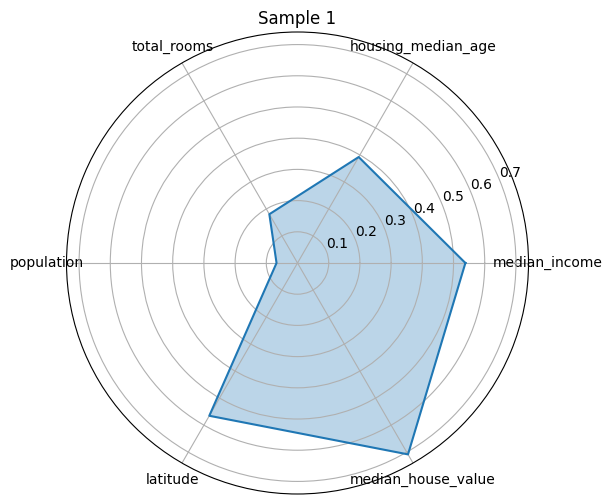

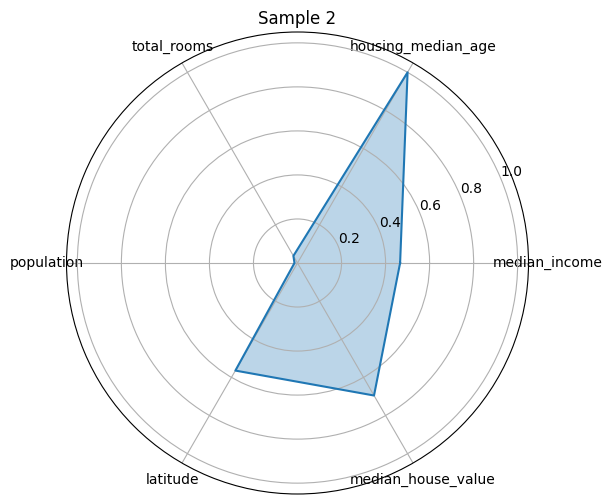

In [30]:
for i in range(3):
    star_plot(
        scaled_data[i],
        features,
        f"Sample {i}"
    )

In [31]:
low = df.nsmallest(1000, "median_house_value")

high = df.nlargest(1000, "median_house_value")

low_avg = scaler.fit_transform(low[features]).mean(axis=0)

high_avg = scaler.fit_transform(high[features]).mean(axis=0)

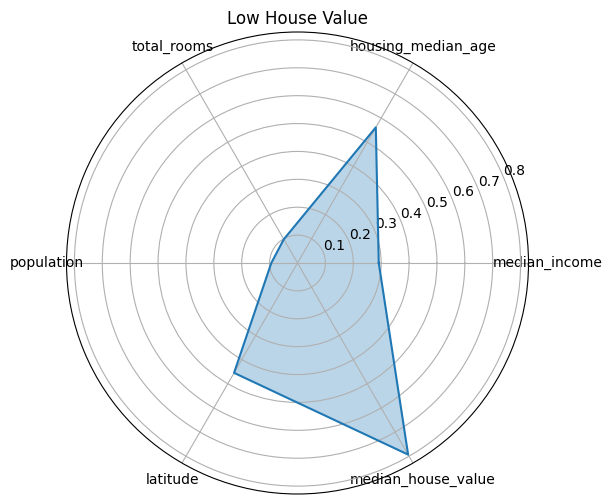

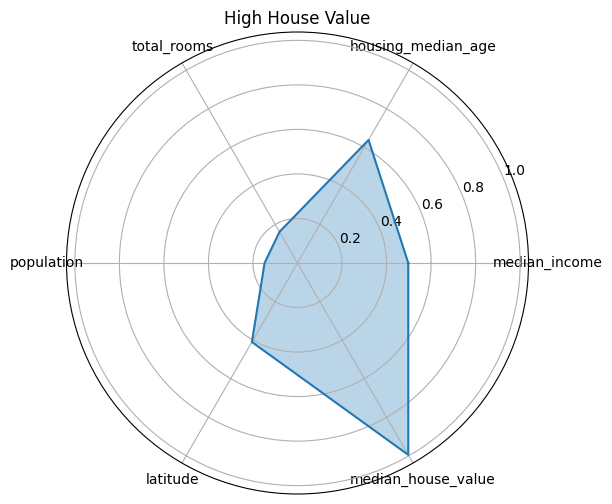

In [32]:
star_plot(
    low_avg,
    features,
    "Low House Value"
)

star_plot(
    high_avg,
    features,
    "High House Value"
)

# Bai 4

In [33]:
features = [
    'median_income',        # kích thước mặt
    'median_house_value',   # kích thước mắt
    'housing_median_age',   # độ cong miệng
    'population'            # kích thước mũi
]

In [34]:
scaler = MinMaxScaler()

samples = scaler.fit_transform(df[features])

In [ ]:
samples = scaler.fit_transform(df[features].sample(9, random_state=42))

In [37]:
def draw_face(ax, data):

    face_size = 0.5 + data[0] * 0.5
    eye_size = 0.05 + data[1] * 0.05
    mouth_curve = data[2] - 0.5
    nose_size = 0.05 + data[3] * 0.05

    # Khuôn mặt
    face = plt.Circle((0.5, 0.5), face_size * 0.4, fill=False, linewidth=2)
    ax.add_patch(face)

    # Mắt
    left_eye = plt.Circle((0.35, 0.6), eye_size, color="black")

    right_eye = plt.Circle((0.65, 0.6), eye_size, color="black")

    ax.add_patch(left_eye)
    ax.add_patch(right_eye)

    # Mũi
    nose = plt.Circle((0.5, 0.5), nose_size, color="black")

    ax.add_patch(nose)

    # Miệng
    x = np.linspace(0.35, 0.65, 100)

    y = 0.35 + mouth_curve * (x - 0.5) ** 2 * -4

    ax.plot(x, y, linewidth=2)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

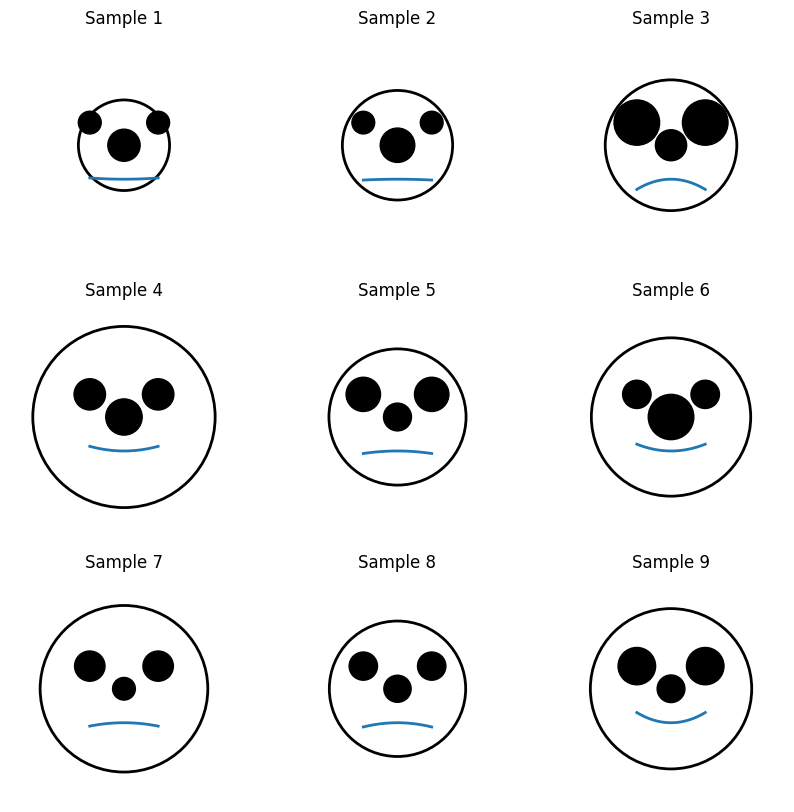

In [38]:
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    draw_face(ax, samples[i])
    ax.set_title(f"Sample {i+1}")

# Bai lam them

c:\Users\LENOVO\AppData\Local\Programs\Python\Python311\Lib\site-packages\joypy\joyplot.py:176: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data.groupby(by)


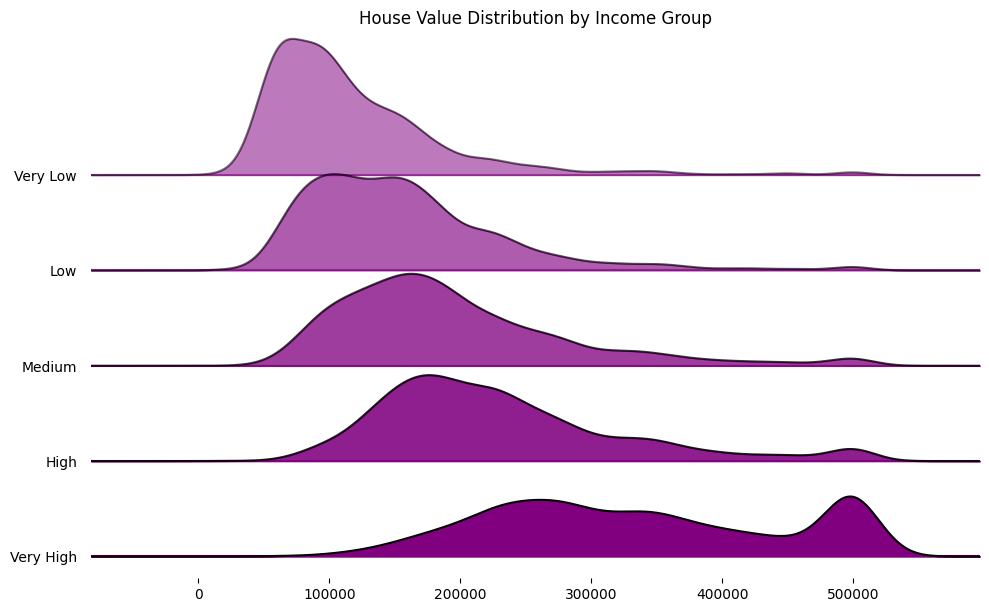

In [47]:
import pandas as pd
import joypy

df["IncomeGroup"] = pd.qcut(
    df["median_income"], q=5, labels=["Very Low", "Low", "Medium", "High", "Very High"]
)

joypy.joyplot(
    data=df,
    by="IncomeGroup",
    column="median_house_value",
    overlap=1,
    fade=True,
    figsize=(10, 6),
    color='purple'
)

plt.title("House Value Distribution by Income Group")
plt.show()